In [1]:
cd /mnt/sda/xxy/Project/ClustView

/mnt/sda/xxy/Project/ClustView


In [2]:
import torch
import numpy as np

from util.pcview import PCViews

device = torch.device("cuda")

# Airplane
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/02691156-1a32f10b20170883663e90eaf6b4ca52.npy'
# name = 'Airplane'

# Bag
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/02773838-1b84dededd445058e44a5473032f38f.npy'
# name = 'Bag'

# Cap
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/02954340-1fc6f3aebca014ab19ba010ddb4974fe.npy'
# name = 'Cap'

# Car
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/02958343-1a56d596c77ad5936fa87a658faf1d26.npy'
# name = 'Car'

# Chair
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/03001627-1a38407b3036795d19fb4103277a6b93.npy'
# name = 'Chair'

# Earphone
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/03261776-1d4f9c324d6388a9b904f4192b538029.npy'
# name = 'Earphone'

# Guitar
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/03467517-1a680e3308f2aac544b2fa2cac0778f5.npy'
# name = 'Guitar'

# Knife
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/03624134-1be1aa66cd8674184e09ebaf49b0cb2f.npy'
# name = 'Knife'

# Lamp
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/03636649-1a6a520652aa2244146fa8a09fad6c38.npy'
# name = 'Lamp'

# Laptop
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/03642806-1b5ec8c5ca53caa5ad6be7ca8dcfc55b.npy'
# name = 'Laptop'

# Motorbike
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/03790512-1e664c94e932ece9883158c0007ed9ba.npy'
# name = 'Motorbike'

# Mug
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/03797390-1a97f3c83016abca21d0de04f408950f.npy'
# name = 'Mug'

# Pistol
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/03948459-1b8adaf6f8c40366c416aa58a067b7bc.npy'
# name = 'Pistol'

# Rocket
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/04099429-1ada292665f218a8789f2aa296a418cc.npy'
# name = 'Rocket'

# Skateboard
# sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/04225987-1c8d5e05c3faa05861be5ced44bc18ac.npy'
# name = 'Skateboard'

# Table
sample = '/mnt/sda/xxy/Dataset/Shapenet/ShapeNet55-34/shapenet_pc/04379243-1a2abbc9712e2fffc3bd24f986301745.npy'
name = 'Table'

sample = np.load(sample).astype('float32')
sample = torch.tensor(sample).unsqueeze(0).to(device)
sample = sample.repeat(2, 1, 1)

pcview = PCViews()

def get_img(inpt):
    B = inpt.shape[0]
    imgs = pcview.get_img(inpt, 256)
    _, H, W = imgs.shape
    imgs = imgs.reshape(B, 6, H, W)

    return imgs

imgs = get_img(sample[:, :, :3])[0]
imgs = imgs.cpu().numpy()
print(imgs.shape)


[2025-04-21 10:37:20,176] [INFO] [real_accelerator.py:161:get_accelerator] Setting ds_accelerator to cuda (auto detect)
(6, 256, 256)


In [3]:
import cv2  # 导入 OpenCV

kernel = np.ones((5, 5), np.uint8)
i = 0
for img in imgs:
    img = (img - np.min(img))/(np.max(img) - np.min(img))*255
    img = img.astype(np.uint8)
    img = cv2.dilate(img,kernel,iterations=1)

    cv2.imwrite(f'./vis_util/visualization/depth/{name}_view_{i+1}.png', img)  # 保存为 PNG 文件
    i += 1

print('Done !')


Done !


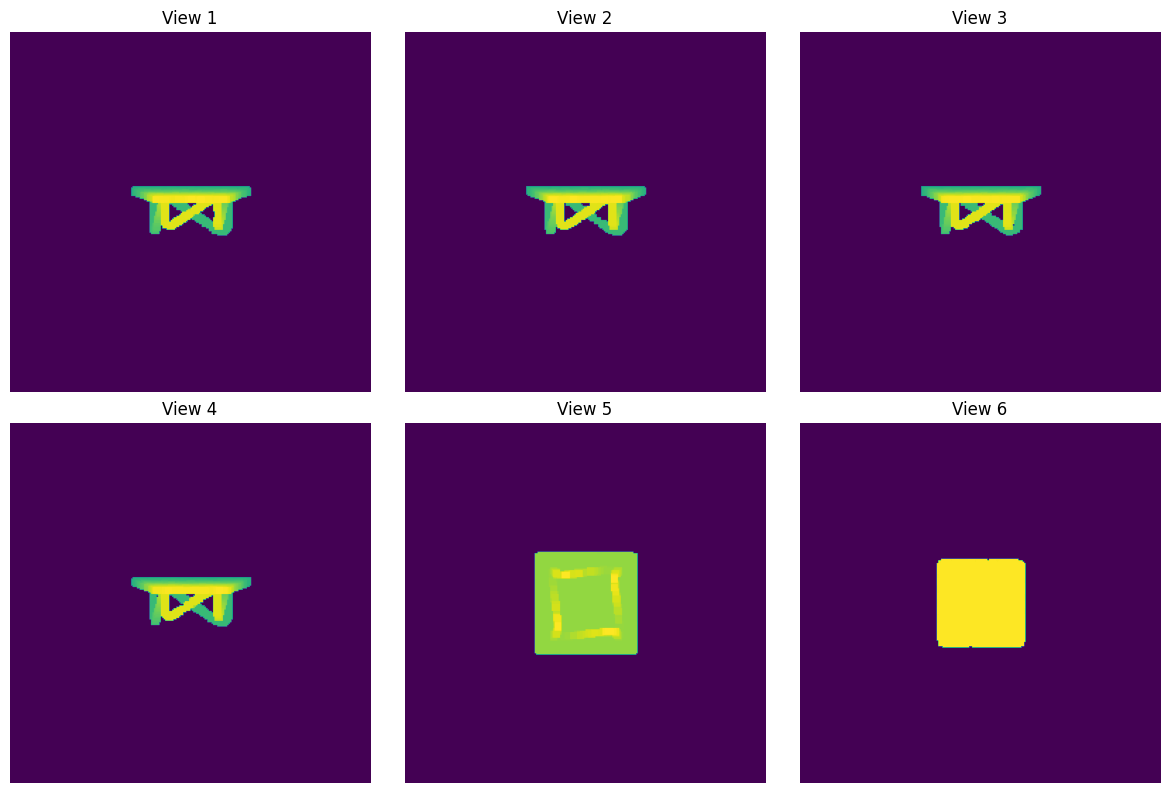

In [4]:
import matplotlib.pyplot as plt

# 创建一个子图布局，每行3个图，共2行
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# 遍历每个视图并进行可视化
for i, ax in enumerate(axes.flat):
    # 获取当前视图
    view = img[i]

    # 显示视图
    ax.imshow(view, cmap='gray')  # 使用灰度颜色映射
    ax.set_title(f'View {i+1}')
    ax.axis('off')  # 关闭坐标轴

# 调整子图之间的间距
plt.tight_layout()

# 保存所有视图为一张图
plt.savefig(f'./vis_util/visualization/depth/{name}_multi_views.png', bbox_inches='tight')

# 单独保存每个视图
for i in range(6):
    plt.figure()
    plt.imshow(img[i], cmap='gray')
    plt.axis('off')
    plt.savefig(f'./vis_util/visualization/depth/{name}_view_{i+1}.png', bbox_inches='tight', pad_inches=0)
    plt.close()

# 显示所有视图
plt.show()